## makes aral sea balance

In [1]:
# setup imports
import sys
from pathlib import Path

PROJECT_ROOT = Path().resolve().parents[1]  # pas aan als notebook dieper/dichter zit
sys.path.append(str(PROJECT_ROOT))

import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

import fiona
import shapely.geometry
from pyproj import Geod



from src.paths import *
from src.forcing import generate_lumped_ERA5_forcing,load_lumped_forcing_data
from src.models import simulate_HBV,save_HBV_results
from src.utils import mmday_to_m3s
import src.aral as aral

/opt/conda/envs/ewatercycle2/lib/python3.12/site-packages/esmvalcore/experimental/_warnings.py:13: UserWarning: 
  Thank you for trying out the new ESMValCore API.
  Note that this API is experimental and may be subject to change.
  More info: https://github.com/ESMValGroup/ESMValCore/issues/498


In [2]:
### generate forcing
experiment_start_date = "1940-01-01T00:00:00Z"
experiment_end_date = "2020-12-31T00:00:00Z"

shapefile_kerki = "Kerki_GRDC"
shapefile_TA = "Tyumen_Aryk_GRDC"
shapefile_Aral = "AralSea"

# ERA5_forcing_kerki = generate_lumped_ERA5_forcing(shapefile_kerki, experiment_start_date, experiment_end_date)
# ERA5_forcing_TA = generate_lumped_ERA5_forcing(shapefile_TA, experiment_start_date, experiment_end_date)
# ERA5_forcing_Aral = generate_lumped_ERA5_forcing(shapefile_Aral, experiment_start_date, experiment_end_date)

In [3]:
### imports

#Parameters HBV model after calibration with CMA-ES:

parameter_set = [
    8.507048,   # Imax
    0.566942,   # Ce
    448.172323, # Sumax
    0.714943,   # Beta
    0.045901,   # Pmax
    2.377915,   # Tlag
    0.011572,   # Kf
    0.004388,   # Ks
    0.422621    # FM
]

# Initial conditions placeholder
initial_conditions = np.array([
    0,      # Si
    100,    # Su
    0,      # Sf
    5,      # Ss
    0       # Sp
])

#kerki simulation
#simulatie_kerki = simulate_HBV(ERA5_forcing_kerki, parameter_set=parameter_set, initial_conditions=initial_conditions)
#kerki_hbv_m3 = mmday_to_m3s(simulatie_kerki, shapefile_kerki)
#saved_files  = save_HBV_results(simulatie_kerki,shape_name=shapefile_kerki, forcing_type="ERA5" )
#print(saved_files)
#simulatie_TA = simulate_HBV(ERA5_forcing_TA, parameter_set  )
#save_HBV_results(simulatie_kerki,shape_name=shapefile_kerki, forcing_type="ERA5" )
#simulatie_Aral = simulate_HBV(ERA5_forcing_Aral, parameter_set  )   



In [4]:
# forcing_TA = load_lumped_forcing_data(shape_name=shapefile_TA, forcing_type="ERA5", year_span="1940-2020")
# simulatie_TA = simulate_HBV(forcing_TA, parameter_set=parameter_set, initial_conditions=initial_conditions)
# save_HBV_results(simulatie_TA,shape_name=shapefile_TA, forcing_type="ERA5" )

In [5]:
import pandas as pd

path_to_kerki = OUTPUT_HBV / "Kerki_GRDC" / "ERA5" / "Kerki_GRDC_ERA5_1940-2020.pkl"
path_to_TA = OUTPUT_HBV / "Tyumen_Aryk_GRDC" / "ERA5" / "Tyumen_Aryk_GRDC_ERA5_1940-2020.pkl"
# Read the pickle
df_kerki = pd.read_pickle(path_to_kerki)
df_TA = pd.read_pickle(path_to_TA)


In [6]:
River_Amu_Darya = aral.River(df_kerki, q_col="m3_s", name= "Amu_Darya")
River_Syr_Darya = aral.River(df_TA, q_col="m3_s", name= "Syr_Darya")

In [7]:
aral_meteo = xr.open_dataset('/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/forcing/output/ERA5/AralSea/1940-2020/work/diagnostic/script/Derived_Makkink_evspsblpot.nc')

In [8]:
initial_volume = 1100
ahv_file = "/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/data/bathymetry/ahv_curve.csv"
ahv_curve = pd.read_csv(ahv_file, sep=';', decimal=',')

df_aral = aral.run_connected_aral_model(
    aral_meteo, #heb ik
    rivers=[River_Amu_Darya], #, River_Syr_Darya], #heb ik
    ahv_csv=ahv_file,
    V0_km3=initial_volume
)



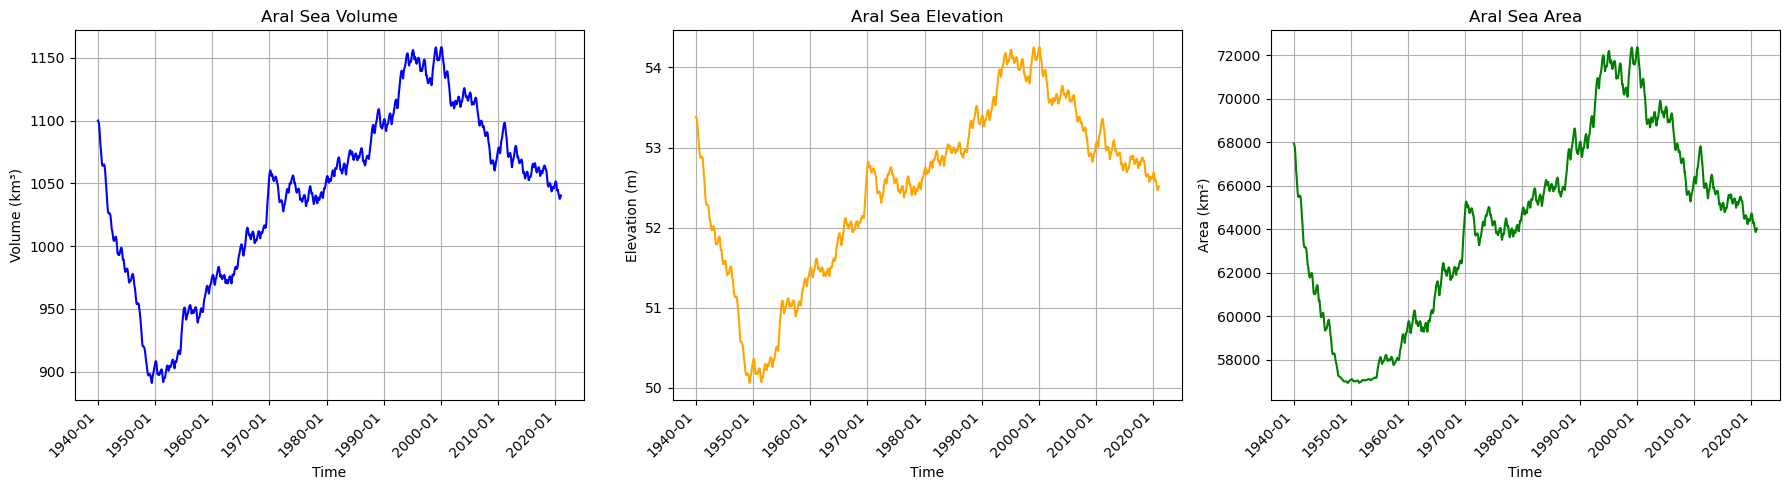

In [9]:
aral.plot_aral_results(df_aral)

In [10]:
df_aral.head()

,time,volume_km3,area_km2,elevation_m,Q_in_km3day,evap_km3day
0,1940-01-01 12:00:00,1100.000000,NaN,NaN,NaN,NaN
1,1940-01-02 12:00:00,1099.979175,67947.027027,53.384095,0.006194,0.027019
2,1940-01-03 12:00:00,1099.957754,67945.451080,53.383785,0.006179,0.027600
3,1940-01-04 12:00:00,1099.943305,67943.830044,53.383467,0.006164,0.020614
4,1940-01-05 12:00:00,1099.927380,67942.736566,53.383252,0.006150,0.022075


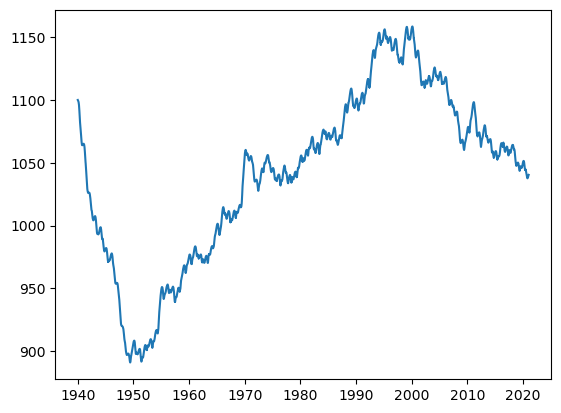

In [11]:
plt.plot(df_aral['time'], df_aral['volume_km3'])


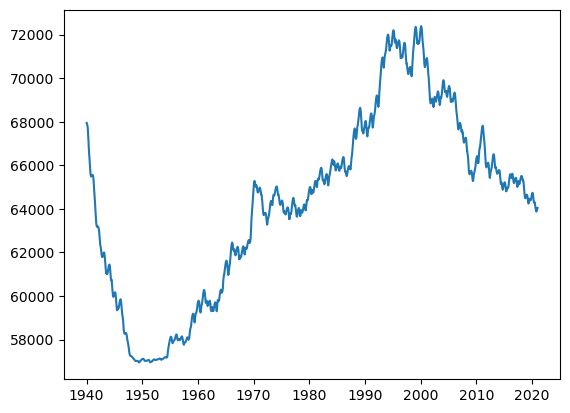

In [12]:
plt.plot(df_aral['time'], df_aral['area_km2'])


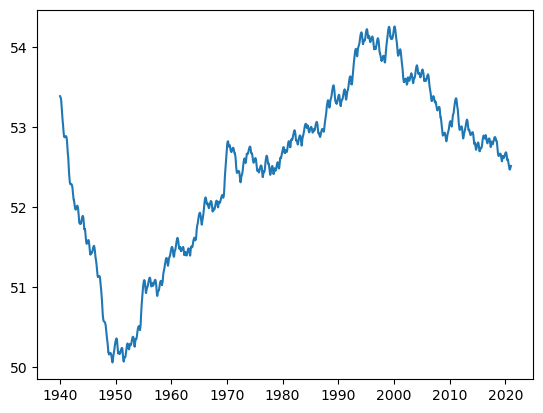

In [13]:
plt.plot(df_aral['time'], df_aral['elevation_m'])

In [14]:
ahv_curve.columns

Index(['elevation_m', 'volume_km3', 'area_km2'], dtype='object')

<Axes: >

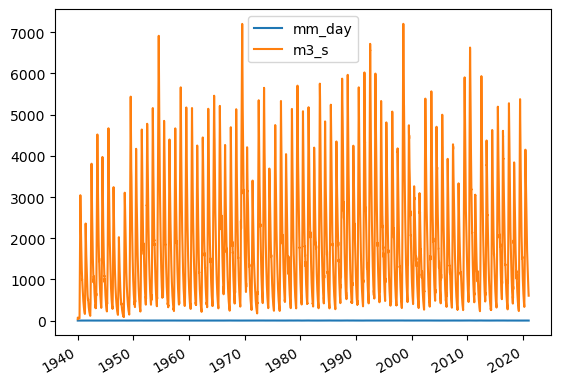

In [15]:
df_kerki.plot()

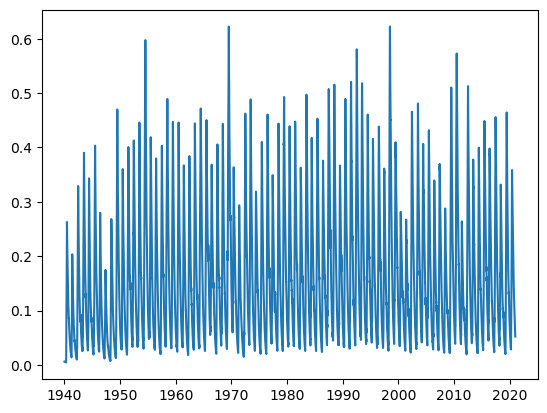

In [16]:
plt.plot(df_aral['time'], df_aral['Q_in_km3day'])

In [17]:
df_aral.head()

,time,volume_km3,area_km2,elevation_m,Q_in_km3day,evap_km3day
0,1940-01-01 12:00:00,1100.000000,NaN,NaN,NaN,NaN
1,1940-01-02 12:00:00,1099.979175,67947.027027,53.384095,0.006194,0.027019
2,1940-01-03 12:00:00,1099.957754,67945.451080,53.383785,0.006179,0.027600
3,1940-01-04 12:00:00,1099.943305,67943.830044,53.383467,0.006164,0.020614
4,1940-01-05 12:00:00,1099.927380,67942.736566,53.383252,0.006150,0.022075


In [18]:
df_kerki.head()

,mm_day,m3_s
1940-01-02 12:00:00,0.010992,35.885418
1940-01-03 12:00:00,0.021959,71.686235
1940-01-04 12:00:00,0.021907,71.517169
1940-01-05 12:00:00,0.021855,71.348341
1940-01-06 12:00:00,0.021804,71.179711


In [19]:
test = aral_meteo["evspsblpot"].isel(time=2).values

In [20]:
aral_meteo["evspsblpot"]

<xarray.DataArray 'evspsblpot' (time: 29586)> Size: 118kB
[29586 values with dtype=float32]
Coordinates:
  * time     (time) datetime64[ns] 237kB 1940-01-01T12:00:00 ... 2020-12-31T1...
    lat      float64 8B ...
    lon      float64 8B ...
Attributes:
    standard_name:  water_potential_evaporation_flux
    units:          kg m-2 s-1
    long_name:      potential evaporation